In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

DRUG_COLS = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]

DRUG_NAMES = {
    "M01AB": "Anti-inflammatory (Diclofenac)",
    "M01AE": "Propionic acid (Ibuprofen)",
    "N02BA": "Salicylic acid (Aspirin)",
    "N02BE": "Anilides (Paracetamol)",
    "N05B" : "Anxiolytics (Diazepam)",
    "N05C" : "Hypnotics (Sleeping aids)",
    "R03"  : "Respiratory (Salbutamol)",
    "R06"  : "Antihistamines (Cetirizine)"
}

daily   = pd.read_csv("C:/Users/Hello User/Downloads/salesdaily.csv",  parse_dates=["datum"])
monthly = pd.read_csv("C:/Users/Hello User/Downloads/salesmonthly.csv", parse_dates=["datum"])

monthly["year"]  = monthly["datum"].dt.year
monthly["month"] = monthly["datum"].dt.month

print("Data loaded ✓")

Data loaded ✓


# Total sales per drug (bar chart)

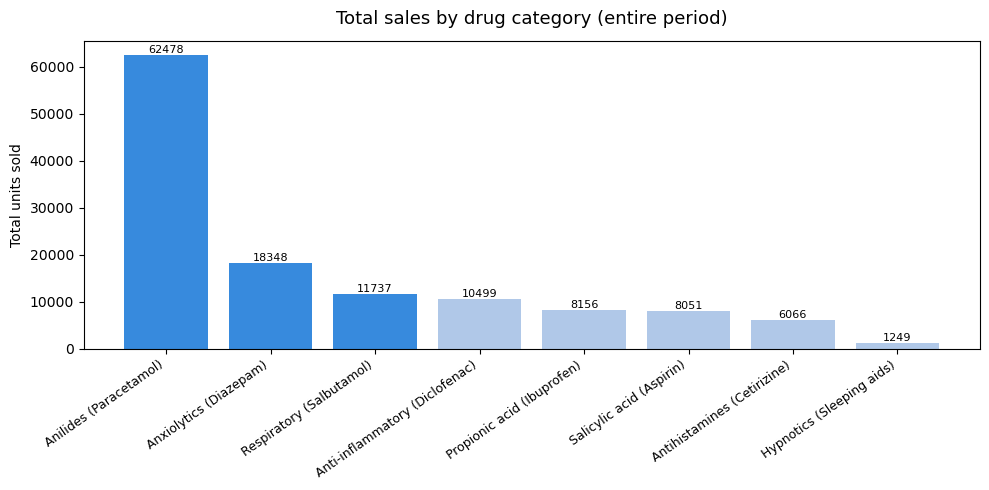

In [11]:
total_sales = monthly[DRUG_COLS].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#378ADD" if i < 3 else "#B0C8E8" for i in range(len(total_sales))]
bars = ax.bar([DRUG_NAMES[d] for d in total_sales.index],
              total_sales.values, color=colors, edgecolor="none")

ax.set_title("Total sales by drug category (entire period)", fontsize=13, pad=12)
ax.set_ylabel("Total units sold")
ax.set_xlabel("")
plt.xticks(rotation=35, ha="right", fontsize=9)

# Add value labels
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{bar.get_height():.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# Monthly trend for each drug (line plots)

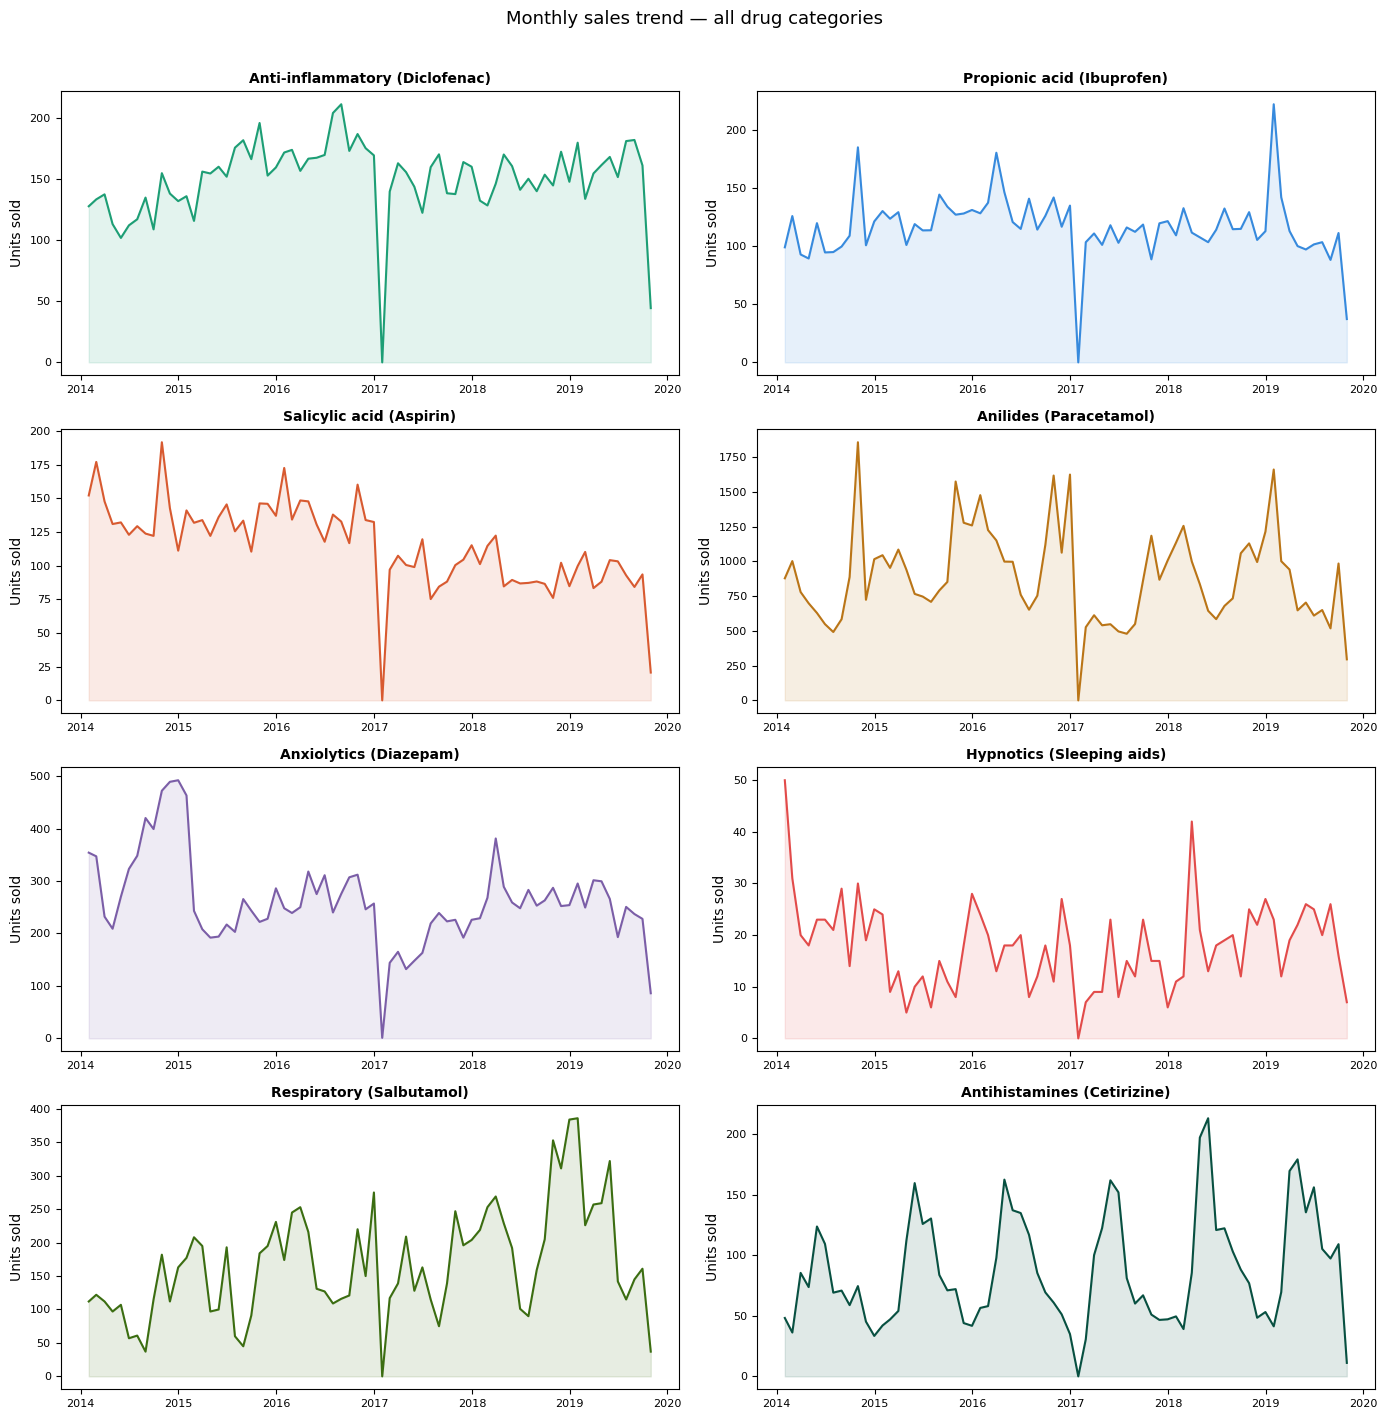

In [13]:
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()
palette = ["#1D9E75","#378ADD","#D85A30","#BA7517",
           "#7B5EA7","#E24B4A","#3B6D11","#085041"]

for i, drug in enumerate(DRUG_COLS):
    ax = axes[i]
    ax.plot(monthly["datum"], monthly[drug],
            color=palette[i], linewidth=1.5)
    ax.fill_between(monthly["datum"], monthly[drug],
                    alpha=0.12, color=palette[i])
    ax.set_title(DRUG_NAMES[drug], fontsize=10, fontweight="bold")
    ax.set_ylabel("Units sold")
    ax.set_xlabel("")
    ax.tick_params(labelsize=8)

plt.suptitle("Monthly sales trend — all drug categories", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Seasonality: average sales by month

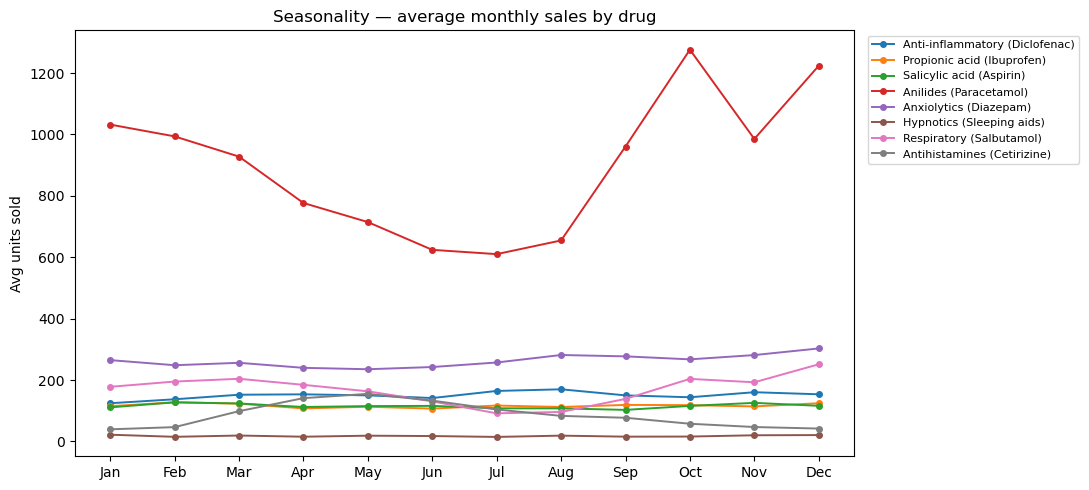

Peak month per drug:
  M01AB : August
  M01AE : February
  N02BA : February
  N02BE : October
  N05B  : December
  N05C  : January
  R03   : December
  R06   : May


In [15]:
seasonality = monthly.groupby("month")[DRUG_COLS].mean()

fig, ax = plt.subplots(figsize=(11, 5))
for drug in DRUG_COLS:
    ax.plot(seasonality.index, seasonality[drug],
            marker="o", markersize=4, label=DRUG_NAMES[drug], linewidth=1.4)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_title("Seasonality — average monthly sales by drug", fontsize=12)
ax.set_ylabel("Avg units sold")
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Key insight
print("Peak month per drug:")
for drug in DRUG_COLS:
    peak = seasonality[drug].idxmax()
    import calendar
    print(f"  {drug:6s}: {calendar.month_name[peak]}")

# Correlation heatmap between drugs

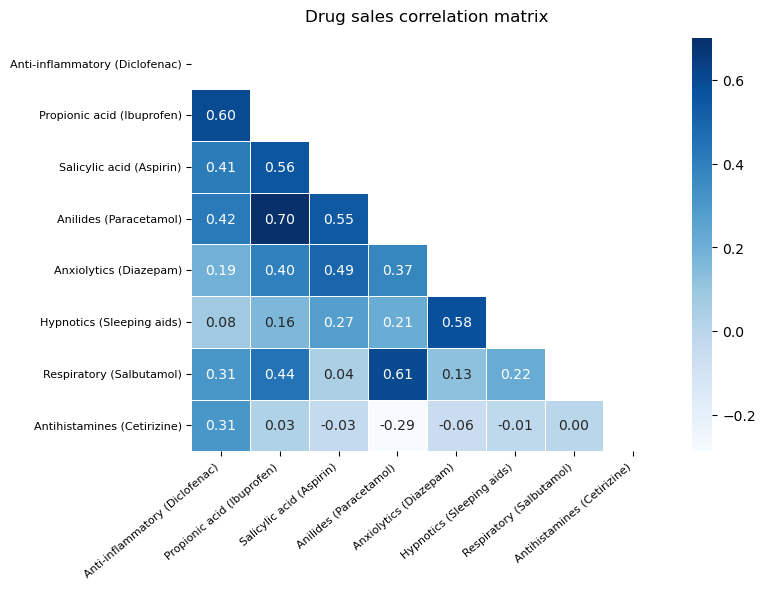

In [17]:
corr_matrix = monthly[DRUG_COLS].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="Blues", linewidths=0.5, ax=ax,
            xticklabels=[DRUG_NAMES[d] for d in DRUG_COLS],
            yticklabels=[DRUG_NAMES[d] for d in DRUG_COLS])
ax.set_title("Drug sales correlation matrix", fontsize=12, pad=12)
plt.xticks(rotation=40, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# YoY growth per drug

Year-over-Year growth (%):
      M01AB  M01AE  N02BA  N02BE   N05B   N05C    R03    R06
year                                                        
2014    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN
2015  26.14  12.22  -4.43  18.85 -31.92 -47.52  39.10  18.68
2016  11.52   7.21   3.49  11.99  10.57  30.19  20.31   8.35
2017 -22.18 -24.30 -34.46 -42.88 -36.62 -31.40 -18.95 -13.66
2018   8.05  14.42   2.99  46.76  57.18  70.42  59.64  30.14
2019 -15.09 -19.60 -21.71 -28.87 -26.35 -19.01 -25.86 -10.30


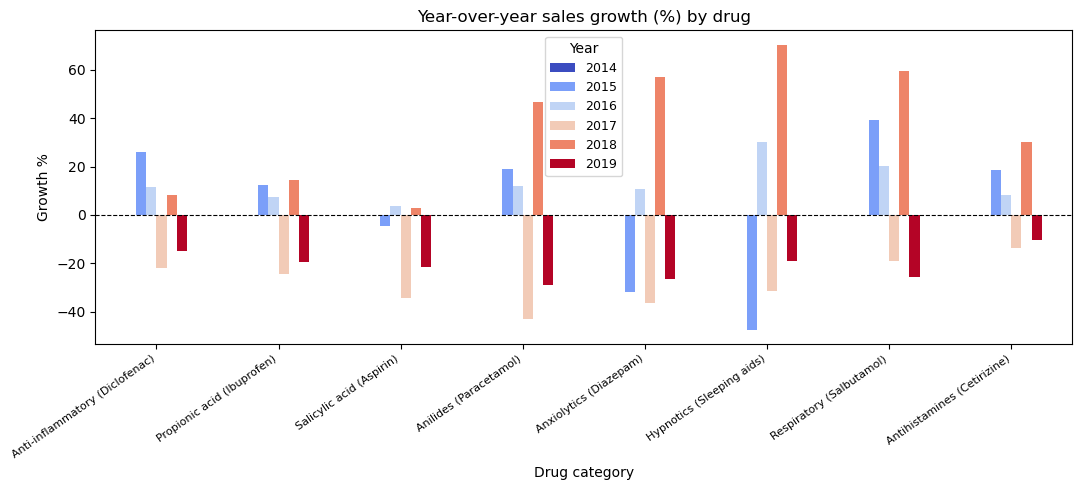

In [19]:
yoy = monthly.groupby("year")[DRUG_COLS].sum()
growth = yoy.pct_change() * 100    # % change year-over-year

print("Year-over-Year growth (%):")
print(growth.round(2).to_string())

growth.T.plot(kind="bar", figsize=(11, 5), colormap="coolwarm", edgecolor="none")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Year-over-year sales growth (%) by drug", fontsize=12)
plt.ylabel("Growth %")
plt.xlabel("Drug category")
plt.xticks([i for i in range(len(DRUG_COLS))],
           [DRUG_NAMES[d] for d in DRUG_COLS], rotation=35, ha="right", fontsize=8)
plt.legend(title="Year", fontsize=9)
plt.tight_layout()
plt.show()